### 10. Load & run interactive GSEA per group

#### 10.1 load packages and data

In [33]:
import os
import pandas as pd
import gseapy as gp
import scanpy as sc

In [34]:
adata_full = sc.read('/storage/users/data/PANC/H5AD_file/adata_filtered_no2D.h5ad')

In [35]:
adata_full

AnnData object with n_obs × n_vars = 5279 × 26000
    obs: 'condition', 'pct_cmo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_scores', 'predicted_doublets', 'outlier', 'leiden'
    var: 'CMO', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_symbol', 'ensembl_gene_id', 'mito', 'ribo', 'n_cells'
    uns: 'condition_colors', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [36]:
adata_sync = sc.read("/storage/users/data/PANC/H5AD_file/adata_full_sync.h5ad")

In [37]:
adata_sync

AnnData object with n_obs × n_vars = 5254 × 26000
    obs: 'condition', 'pct_cmo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_scores', 'predicted_doublets', 'outlier', 'leiden', 'leiden_t_bin_merged_nicer', 't', 'milestones'
    var: 'CMO', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_symbol', 'ensembl_gene_id', 'mito', 'ribo', 'n_cells'
    uns: 'condition_colors', 'leiden', 'leiden_t_bin_merged_nicer_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [38]:
# ─── 0.  Load the annotated expression table ──────────────────────────────────
in_path = "/storage/users/job37yv/Projects/PANC_cancer/analysis/network_module_gsea/expr_mean_filtered_with_cluster.csv"
df = pd.read_csv(in_path)
print(f"Loaded {df.shape[0]} genes × {df.shape[1]} cols")


Loaded 895 genes × 18 cols


In [39]:
df

,Unnamed: 0,UniProtID,gene_symbol,cluster_id,0_t_0.0000-0.5000,3_t_1.0000-1.5000,3_t_0.0000-1.0000,3_t_1.5000-2.5000,2_t_3.5000-4.0000,1_t_0.5000-1.5000,2_t_1.0000-2.5000,1_t_3.0000-3.5000,1_t_1.5000-2.5000,1_t_2.5000-3.0000,2_t_2.5000-3.0000,2_t_3.0000-3.5000,UniProtID.1,gene_symbol.1
0,ENSG00000107404,O14640,DVL1,5,0.224959,0.198402,0.160796,0.226580,0.254300,0.177306,0.154606,0.319653,0.223975,0.249439,0.134558,0.240045,O14640,DVL1
1,ENSG00000175756,Q9NWT8,AURKAIP1,2,1.099698,1.311709,1.142508,1.328846,1.164289,1.064719,1.366985,0.912235,0.981153,1.052619,1.240800,1.217157,Q9NWT8,AURKAIP1
2,ENSG00000221978,Q96S94,CCNL2,11,0.190749,0.179578,0.179172,0.188419,0.206964,0.192313,0.174532,0.223075,0.295529,0.229525,0.205282,0.218899,Q96S94,CCNL2
3,ENSG00000160075,Q9NP77,SSU72,3,0.649238,0.651704,0.720787,0.763472,0.739532,0.714208,0.870415,0.712790,0.760473,0.684356,0.608175,0.693279,Q9NP77,SSU72
4,ENSG00000248333,P21127,CDK11B,18,0.178145,0.252922,0.242448,0.422166,0.257800,0.263451,0.456546,0.185793,0.218766,0.170367,0.282530,0.324324,P21127,CDK11B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890,ENSG00000102030,P41227,NAA10,6,0.660496,0.802180,0.613306,0.887937,0.835646,0.695922,0.850929,0.672348,0.788046,0.713414,0.786389,0.866688,P41227,NAA10
891,ENSG00000184216,P51617,IRAK1,10,0.270550,0.354947,0.295402,0.487896,0.572700,0.489389,0.410977,0.415222,0.488162,0.452862,0.476003,0.540326,P51617,IRAK1
892,ENSG00000169057,P51608,MECP2,14,0.657816,0.688199,0.662358,0.707481,0.675390,0.760083,0.790807,0.647599,0.740625,0.683994,0.730910,0.683252,P51608,MECP2
893,ENSG00000196924,P21333,FLNA,0,0.683613,0.741023,0.509371,0.659705,1.203602,0.663707,0.520601,1.308083,0.738295,1.079603,0.676619,0.943242,P21333,FLNA


#### 10.2 build new adata object

In [42]:
import anndata as ad
import pandas as pd
import os

df = df.rename(columns={"Unnamed: 0": "ensembl_gene_id"})
# drop duplicated UniProtID.1 and gene_symbol.1 columns
df = df.loc[:, ~df.columns.str.endswith(".1")]

# 3) Build mapping dicts
ens_list = df["ensembl_gene_id"].tolist()
ens2up   = dict(zip(df["ensembl_gene_id"], df["UniProtID"]))
ens2sym  = dict(zip(df["ensembl_gene_id"], df["gene_symbol"]))
ens2cl   = dict(zip(df["ensembl_gene_id"], df["cluster_id"]))

# 4) Subset adata_sync to only those Ensembl genes
keep = [g for g in adata_sync.var_names if g in ens_list]
adata_sub = adata_sync[:, keep].copy()

# 5) Reorder to match df order
adata_sub = adata_sub[:, ens_list].copy()

# 6) Switch var_names to UniProtID and annotate var
uni_ids = [ens2up[ens] for ens in adata_sub.var_names]
adata_sub.var_names = uni_ids
adata_sub.var["ensembl_gene_id"] = ens_list
adata_sub.var["gene_symbol"]      = [ens2sym[ens] for ens in ens_list]
adata_sub.var["cluster_id"]       = [ens2cl[ens]  for ens in ens_list]

# 7) Save the new AnnData
out_path = (
    "/storage/users/job37yv/Projects/PANC_cancer/analysis"
    "/network_module_gsea/adata_sync_modules.h5ad"
)
os.makedirs(os.path.dirname(out_path), exist_ok=True)
adata_sub.write_h5ad(out_path)

print(f"New AnnData: {adata_sub.n_obs} cells × {adata_sub.n_vars} genes")
print("Var annotation columns:", list(adata_sub.var.columns))


New AnnData: 5254 cells × 895 genes
Var annotation columns: ['CMO', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_symbol', 'ensembl_gene_id', 'mito', 'ribo', 'n_cells', 'cluster_id']


In [43]:
adata_sub

AnnData object with n_obs × n_vars = 5254 × 895
    obs: 'condition', 'pct_cmo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_scores', 'predicted_doublets', 'outlier', 'leiden', 'leiden_t_bin_merged_nicer', 't', 'milestones'
    var: 'CMO', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_symbol', 'ensembl_gene_id', 'mito', 'ribo', 'n_cells', 'cluster_id'
    uns: 'condition_colors', 'leiden', 'leiden_t_bin_merged_nicer_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

#### 10. 3 perform GSEA

In [49]:
import os
import scanpy as sc
import pandas as pd
import gseapy as gp

# ─── 1. Build UniProt‐based gene‐sets ─────────────────────────────────────────
# adata_sub.var_names are UniProt IDs, adata_sub.var["cluster_id"] holds your modules
cluster2genes = {
    f"cluster_{cid}": adata_sub.var_names[
                          adata_sub.var["cluster_id"] == cid
                      ].tolist()
    for cid in adata_sub.var["cluster_id"].unique()
}

# ─── 2. DE + prerank for each bin vs baseline ────────────────────────────────
baseline = "0_t_0.0000-0.5000"
bins     = [
    b for b in adata_sub.obs["leiden_t_bin_merged_nicer"].cat.categories
    if b != baseline
]

outdir = (
    "/storage/users/job37yv/Projects/PANC_cancer/analysis/"
    "network_module_gsea/prerank_de_results"
)
os.makedirs(outdir, exist_ok=True)

for b in bins:
    print(f"\n>>> DE & GSEA for {b} vs {baseline}")

    # 2a) Run DE (Wilcoxon)
    sc.tl.rank_genes_groups(
        adata_sub,
        groupby   = "leiden_t_bin_merged_nicer",
        groups    = [b],
        reference = baseline,
        method    = "wilcoxon"
    )

    # 2b) Extract DE results
    de_df = sc.get.rank_genes_groups_df(adata_sub, group=b)
    de_df = de_df.dropna(subset=["logfoldchanges", "names"])
    de_df = de_df[~de_df["names"].duplicated()]

    # 2c) Build prerank: index=UniProtID, value=log2FC
    rnk = pd.Series(
        de_df["logfoldchanges"].values,
        index=de_df["names"]  # these are UniProt IDs
    ).sort_values(ascending=False)

    # 2d) Run prerank GSEA with relaxed size filters
    res = gp.prerank(
        rnk             = rnk,
        gene_sets       = cluster2genes,
        threads         = 4,
        permutation_num = 1000,
        min_size        = 3,       # allow small modules
        max_size        = 2000,    # up to whole network
        outdir          = os.path.join(outdir, b.replace("/", "_")),
        seed            = 0,
        verbose         = True
    )

    # 2e) Save results
    res.res2d.to_csv(
        os.path.join(outdir, f"gsea_de_prerank_{b}.csv")
    )
    print(f"  • {res.res2d.shape[0]} enriched modules saved.")

print("\nAll done!")



>>> DE & GSEA for 1_t_0.5000-1.5000 vs 0_t_0.0000-0.5000


2025-05-15 11:37:21,104 [INFO] Parsing data files for GSEA.............................
2025-05-15 11:37:21,105 [INFO] 0033 gene_sets have been filtered out when max_size=2000 and min_size=3
2025-05-15 11:37:21,105 [INFO] 0028 gene_sets used for further statistical testing.....
2025-05-15 11:37:21,106 [INFO] Start to run GSEA...Might take a while..................
2025-05-15 11:37:22,066 [INFO] Start to generate gseapy reports, and produce figures...
2025-05-15 11:37:22,066 [INFO] Congratulations. GSEApy runs successfully................



  • 28 enriched modules saved.

>>> DE & GSEA for 1_t_1.5000-2.5000 vs 0_t_0.0000-0.5000


2025-05-15 11:37:22,400 [INFO] Parsing data files for GSEA.............................
2025-05-15 11:37:22,401 [INFO] 0033 gene_sets have been filtered out when max_size=2000 and min_size=3
2025-05-15 11:37:22,401 [INFO] 0028 gene_sets used for further statistical testing.....
2025-05-15 11:37:22,402 [INFO] Start to run GSEA...Might take a while..................
2025-05-15 11:37:22,809 [INFO] Start to generate gseapy reports, and produce figures...
2025-05-15 11:37:22,810 [INFO] Congratulations. GSEApy runs successfully................



  • 28 enriched modules saved.

>>> DE & GSEA for 1_t_2.5000-3.0000 vs 0_t_0.0000-0.5000


...

  • 28 enriched modules saved.

>>> DE & GSEA for 3_t_1.0000-1.5000 vs 0_t_0.0000-0.5000


2025-05-15 11:37:32,621 [INFO] Parsing data files for GSEA.............................
2025-05-15 11:37:32,622 [INFO] 0033 gene_sets have been filtered out when max_size=2000 and min_size=3
2025-05-15 11:37:32,622 [INFO] 0028 gene_sets used for further statistical testing.....
2025-05-15 11:37:32,623 [INFO] Start to run GSEA...Might take a while..................
2025-05-15 11:37:33,830 [INFO] Start to generate gseapy reports, and produce figures...
2025-05-15 11:37:33,830 [INFO] Congratulations. GSEApy runs successfully................

2025-05-15 11:37:33,997 [INFO] Parsing data files for GSEA.............................
2025-05-15 11:37:33,998 [INFO] 0033 gene_sets have been filtered out when max_size=2000 and min_size=3
2025-05-15 11:37:33,998 [INFO] 0028 gene_sets used for further statistical testing.....
2025-05-15 11:37:33,999 [INFO] Start to run GSEA...Might take a while..................


  • 28 enriched modules saved.

>>> DE & GSEA for 3_t_1.5000-2.5000 vs 0_t_0.0000-0.5000


2025-05-15 11:37:35,044 [INFO] Start to generate gseapy reports, and produce figures...
2025-05-15 11:37:35,045 [INFO] Congratulations. GSEApy runs successfully................



  • 28 enriched modules saved.

All done!


In [48]:
adata_sub

AnnData object with n_obs × n_vars = 5254 × 895
    obs: 'condition', 'pct_cmo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_scores', 'predicted_doublets', 'outlier', 'leiden', 'leiden_t_bin_merged_nicer', 't', 'milestones'
    var: 'CMO', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_symbol', 'ensembl_gene_id', 'mito', 'ribo', 'n_cells', 'cluster_id'
    uns: 'condition_colors', 'leiden', 'leiden_t_bin_merged_nicer_colors', 'log1p', 'neighbors', 'pca', 'umap', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

#### 10.3 visualize results

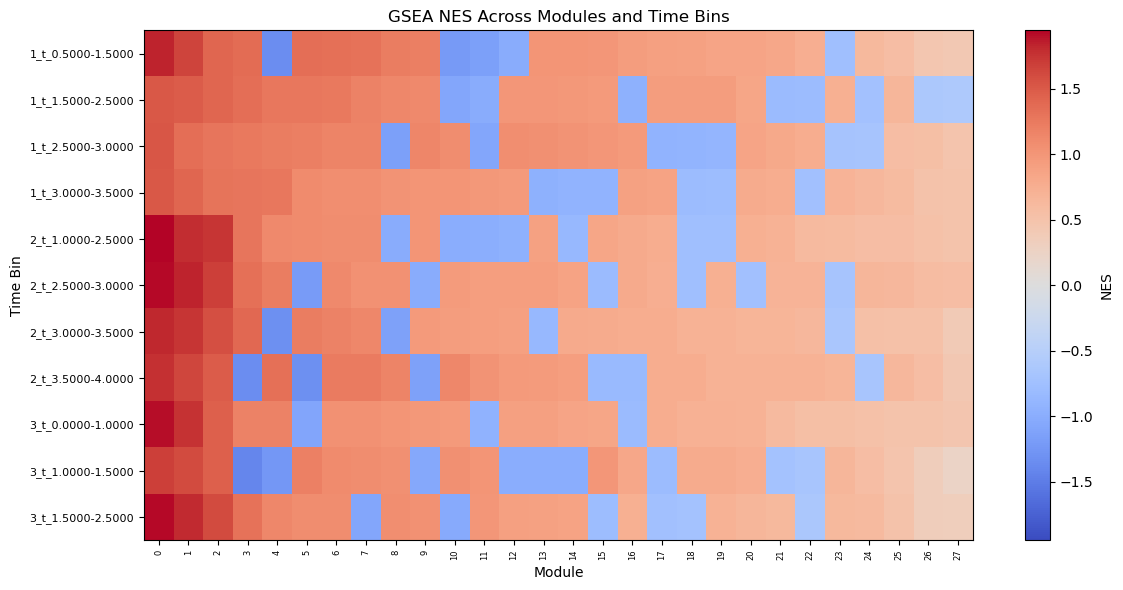

In [50]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Locate prerank result files
prerank_dir = "/storage/users/job37yv/Projects/PANC_cancer/analysis/network_module_gsea/prerank_de_results"
files = sorted(f for f in os.listdir(prerank_dir) if f.startswith("gsea_de_prerank_") and f.endswith(".csv"))

# 2. Read NES from each file
nes_data = {}
for fname in files:
    bin_name = fname.replace("gsea_de_prerank_", "").replace(".csv", "")
    df = pd.read_csv(os.path.join(prerank_dir, fname), index_col=0)
    if "NES" in df.columns:
        nes_data[bin_name] = df["NES"]

# 3. Build matrix (Time bins × Modules)
nes_df = pd.DataFrame(nes_data).T  # rows=time bins, cols=module names
nes_df = nes_df.sort_index()

# 4. Sort modules by overall |NES| (mean absolute NES)
module_order = nes_df.abs().mean().sort_values(ascending=False).index.tolist()
nes_df = nes_df[module_order]

# 5. Prepare data for heatmap
data = nes_df.values.astype(float)
vlim = np.nanmax(np.abs(data))
masked = np.ma.masked_invalid(data)

# 6. Plot refined heatmap
plt.figure(figsize=(12, 6))
cmap = plt.cm.coolwarm
im = plt.imshow(masked, aspect="auto", cmap=cmap, vmin=-vlim, vmax=vlim)
plt.colorbar(im, label="NES")

# Ticks
plt.yticks(np.arange(len(nes_df.index)), nes_df.index, fontsize=8)
plt.xticks(np.arange(len(nes_df.columns)), nes_df.columns, rotation=90, fontsize=6)

# Gridlines for readability
plt.grid(False)
plt.title("GSEA NES Across Modules and Time Bins", fontsize=12)
plt.xlabel("Module", fontsize=10)
plt.ylabel("Time Bin", fontsize=10)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2397109/865705963.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


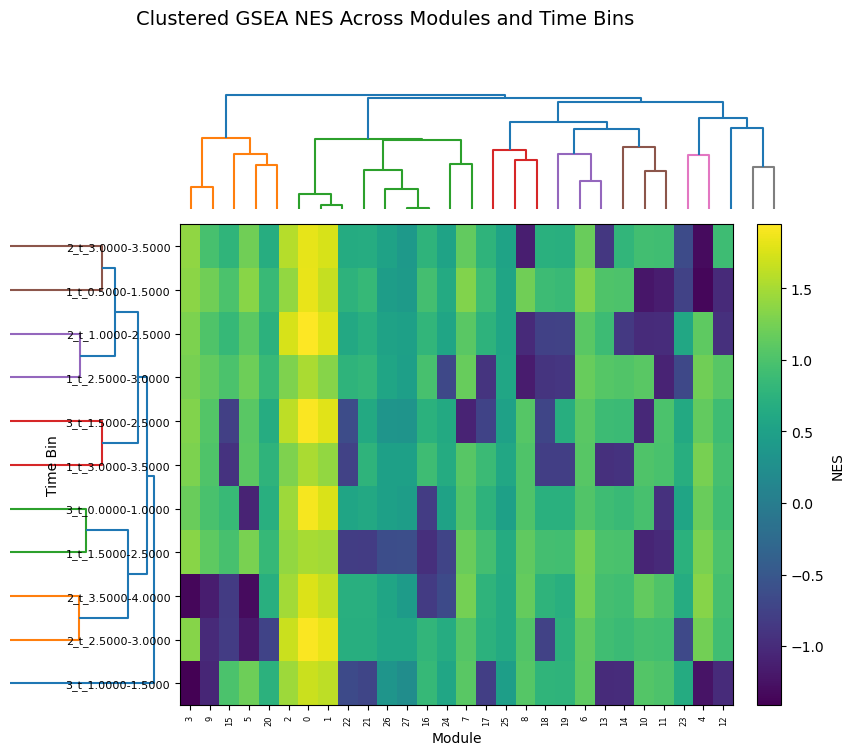

In [51]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from matplotlib.gridspec import GridSpec

# 1. Locate prerank DE result files
prerank_dir = "/storage/users/job37yv/Projects/PANC_cancer/analysis/network_module_gsea/prerank_de_results"
files = sorted(f for f in os.listdir(prerank_dir)
               if f.startswith("gsea_de_prerank_") and f.endswith(".csv"))

# 2. Read NES from each file
nes_data = {}
for fname in files:
    bin_name = fname.replace("gsea_de_prerank_", "").replace(".csv", "")
    df = pd.read_csv(os.path.join(prerank_dir, fname), index_col=0)
    if "NES" in df.columns:
        nes_data[bin_name] = df["NES"]

# 3. Build matrix (Time bins × Modules)
nes_df = pd.DataFrame(nes_data).T
nes_df = nes_df.sort_index()

# 4. Compute linkage for rows (bins) and columns (modules)
row_linkage = sch.linkage(nes_df.values, method='average', metric='correlation')
col_linkage = sch.linkage(nes_df.values.T, method='average', metric='correlation')

# 5. Extract ordering from the dendrograms
row_order = sch.dendrogram(row_linkage, no_plot=True)['leaves']
col_order = sch.dendrogram(col_linkage, no_plot=True)['leaves']

# 6. Reorder the data
data        = nes_df.values[np.ix_(row_order, col_order)]
row_labels  = nes_df.index[row_order].tolist()
col_labels  = nes_df.columns[col_order].tolist()

# 7. Create figure with GridSpec
fig = plt.figure(figsize=(10, 8))
gs  = GridSpec(2, 2, width_ratios=[1,4], height_ratios=[1,4],
               wspace=0.05, hspace=0.05)

ax_col = fig.add_subplot(gs[0,1])
ax_row = fig.add_subplot(gs[1,0])
ax_heat = fig.add_subplot(gs[1,1])

# Column dendrogram
sch.dendrogram(col_linkage, ax=ax_col, orientation='top', no_labels=True)
ax_col.axis('off')

# Row dendrogram
sch.dendrogram(row_linkage, ax=ax_row, orientation='right', no_labels=True)
ax_row.axis('off')

# Heatmap
im = ax_heat.imshow(data, aspect='auto', origin='lower')
ax_heat.set_xticks(np.arange(len(col_labels)))
ax_heat.set_xticklabels(col_labels, rotation=90, fontsize=6)
ax_heat.set_yticks(np.arange(len(row_labels)))
ax_heat.set_yticklabels(row_labels, fontsize=8)

# Colorbar
cbar = fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label("NES")

# Labels & Title
ax_heat.set_xlabel("Module")
ax_heat.set_ylabel("Time Bin")
fig.suptitle("Clustered GSEA NES Across Modules and Time Bins", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [56]:
df

,ensembl_gene_id,UniProtID,gene_symbol,cluster_id,0_t_0.0000-0.5000,3_t_1.0000-1.5000,3_t_0.0000-1.0000,3_t_1.5000-2.5000,2_t_3.5000-4.0000,1_t_0.5000-1.5000,2_t_1.0000-2.5000,1_t_3.0000-3.5000,1_t_1.5000-2.5000,1_t_2.5000-3.0000,2_t_2.5000-3.0000,2_t_3.0000-3.5000
0,ENSG00000107404,O14640,DVL1,5,0.224959,0.198402,0.160796,0.226580,0.254300,0.177306,0.154606,0.319653,0.223975,0.249439,0.134558,0.240045
1,ENSG00000175756,Q9NWT8,AURKAIP1,2,1.099698,1.311709,1.142508,1.328846,1.164289,1.064719,1.366985,0.912235,0.981153,1.052619,1.240800,1.217157
2,ENSG00000221978,Q96S94,CCNL2,11,0.190749,0.179578,0.179172,0.188419,0.206964,0.192313,0.174532,0.223075,0.295529,0.229525,0.205282,0.218899
3,ENSG00000160075,Q9NP77,SSU72,3,0.649238,0.651704,0.720787,0.763472,0.739532,0.714208,0.870415,0.712790,0.760473,0.684356,0.608175,0.693279
4,ENSG00000248333,P21127,CDK11B,18,0.178145,0.252922,0.242448,0.422166,0.257800,0.263451,0.456546,0.185793,0.218766,0.170367,0.282530,0.324324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890,ENSG00000102030,P41227,NAA10,6,0.660496,0.802180,0.613306,0.887937,0.835646,0.695922,0.850929,0.672348,0.788046,0.713414,0.786389,0.866688
891,ENSG00000184216,P51617,IRAK1,10,0.270550,0.354947,0.295402,0.487896,0.572700,0.489389,0.410977,0.415222,0.488162,0.452862,0.476003,0.540326
892,ENSG00000169057,P51608,MECP2,14,0.657816,0.688199,0.662358,0.707481,0.675390,0.760083,0.790807,0.647599,0.740625,0.683994,0.730910,0.683252
893,ENSG00000196924,P21333,FLNA,0,0.683613,0.741023,0.509371,0.659705,1.203602,0.663707,0.520601,1.308083,0.738295,1.079603,0.676619,0.943242


In [55]:
g_nx

# Trash

## GSEA iterative

In [6]:
import os
import pandas as pd
import gseapy as gp


# ─── 1.  Build gene‐sets: cluster_id → list of UniProtIDs ─────────────────────
# Use string keys like "cluster_5" so gseapy is happy
cluster2genes = {
    f"cluster_{cid}": genes
    for cid, genes in df.groupby("cluster_id")["UniProtID"]
                   .apply(list)
                   .items()
}
print(f"{len(cluster2genes)} clusters → gene‐sets")

# (Optional) write a GMT file
gmt = os.path.splitext(in_path)[0] + ".gmt"
with open(gmt, "w") as f:
    for name, genes in cluster2genes.items():
        line = [name, name] + genes
        f.write("\t".join(line) + "\n")
print("Wrote GMT to", gmt)

# ─── 2.  Identify the time‐bin columns ────────────────────────────────────────
time_bins = [c for c in df.columns if c not in ("UniProtID","gene_symbol","cluster_id")]
print("Bins:", time_bins)

# ─── 3.  Run prerank GSEA per bin ─────────────────────────────────────────────
outdir = os.path.join(os.path.dirname(in_path), "prerank_results")
os.makedirs(outdir, exist_ok=True)

for bin_name in time_bins:
    print(f"\n→ GSEA for {bin_name}")
    # 3a) ranking: UniProtID → mean expression
    rank = df.set_index("UniProtID")[bin_name].sort_values(ascending=False)

    prerank_res = gp.prerank(
        rnk            = rank,
        gene_sets      = cluster2genes,
        threads        = 40,
        permutation_num= 1000,
        outdir         = os.path.join(outdir, bin_name.replace("/", "_")),
        seed           = 42
    )

    # 3b) save results
    res_df = prerank_res.res2d
    csv_path = os.path.join(outdir, f"gsea_prerank_{bin_name}.csv")
    res_df.to_csv(csv_path)
    print(f"  • {res_df.shape[0]} terms → {csv_path}")


Loaded 895 genes × 17 cols
61 clusters → gene‐sets
Wrote GMT to /storage/users/job37yv/Projects/PANC_cancer/analysis/network_module_gsea/expr_mean_filtered_with_cluster.gmt
Bins: ['0_t_0.0000-0.5000', '3_t_1.0000-1.5000', '3_t_0.0000-1.0000', '3_t_1.5000-2.5000', '2_t_3.5000-4.0000', '1_t_0.5000-1.5000', '2_t_1.0000-2.5000', '1_t_3.0000-3.5000', '1_t_1.5000-2.5000', '1_t_2.5000-3.0000', '2_t_2.5000-3.0000', '2_t_3.0000-3.5000', 'UniProtID.1', 'gene_symbol.1']

→ GSEA for 0_t_0.0000-0.5000
  • 13 terms → /storage/users/job37yv/Projects/PANC_cancer/analysis/network_module_gsea/prerank_results/gsea_prerank_0_t_0.0000-0.5000.csv

→ GSEA for 3_t_1.0000-1.5000
  • 13 terms → /storage/users/job37yv/Projects/PANC_cancer/analysis/network_module_gsea/prerank_results/gsea_prerank_3_t_1.0000-1.5000.csv

→ GSEA for 3_t_0.0000-1.0000
  • 13 terms → /storage/users/job37yv/Projects/PANC_cancer/analysis/network_module_gsea/prerank_results/gsea_prerank_3_t_0.0000-1.0000.csv

→ GSEA for 3_t_1.5000-2.5000

/home/job37yv/miniforge3/envs/gsea/lib/python3.9/site-packages/gseapy/gsea.py:458: RuntimeWarning: invalid value encountered in scalar divide
  dups = rank_metric.apply(lambda df: df.duplicated().sum() / df.size)
/home/job37yv/miniforge3/envs/gsea/lib/python3.9/site-packages/gseapy/gsea.py:458: RuntimeWarning: invalid value encountered in scalar divide
  dups = rank_metric.apply(lambda df: df.duplicated().sum() / df.size)
